# Food Recommendation System
### Zakaria Narjis — Multi-Algorithm Comparison with Full Evaluation

**Objective:** Build and compare multiple recommendation algorithms for food.com recipes dataset.

**Algorithms compared:**
1. KNN Cosine *(original baseline)*
2. KNN Euclidean *(distance-sensitive variant)*
3. K-Means Clustering *(scalable cluster-then-rank)*
4. SVD Latent Features *(dimensionality reduction)*
5. TF-IDF Ingredient Similarity *(content-based on text)*

**Problem framing:** Unsupervised, offline, model-based — personalised nutrition matching.

## 1. Framing the Problem

**Business objective:** Recommend recipes matching a user's nutritional needs & ingredient preferences to improve user engagement on food platforms.

**Solution use:** Website or mobile app integration.

**ML framing:** Unsupervised, offline, model-based learning — no labelled user-recipe ratings required at inference time.

**Evaluation challenge:** Without explicit user ratings, we use *proxy metrics*: nutritional closeness to target, recommendation diversity, coverage, and inference speed.

## 2. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import tensorflow as tf
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances, euclidean_distances

warnings.filterwarnings('ignore')
np.random.seed(42)

print('TensorFlow version:', tf.__version__)
print('All libraries loaded.')

TensorFlow version: 2.21.0
All libraries loaded.


## 3. Getting the Data

In [3]:
data = pd.read_csv('recipes.csv')
print('Raw shape:', data.shape)
data.head()

Raw shape: (522517, 28)


,RecipeId,Name,AuthorId,AuthorName,CookTime,PrepTime,TotalTime,DatePublished,Description,Images,...,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions
0,38,Low-Fat Berry Blue Frozen Dessert,1533,Dancer,PT24H,PT45M,PT24H45M,1999-08-09T21:46:00Z,Make and share this Low-Fat Berry Blue Frozen ...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,1.3,8.0,29.8,37.1,3.6,30.2,3.2,4.0,NaN,"c(""Toss 2 cups berries with sugar."", ""Let stan..."
1,39,Biryani,1567,elly9812,PT25M,PT4H,PT4H25M,1999-08-29T13:12:00Z,Make and share this Biryani recipe from Food.com.,"c(""https://img.sndimg.com/food/image/upload/w_...",...,16.6,372.8,368.4,84.4,9.0,20.4,63.4,6.0,NaN,"c(""Soak saffron in warm milk for 5 minutes and..."
2,40,Best Lemonade,1566,Stephen Little,PT5M,PT30M,PT35M,1999-09-05T19:52:00Z,This is from one of my first Good House Keepi...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,0.0,0.0,1.8,81.5,0.4,77.2,0.3,4.0,NaN,"c(""Into a 1 quart Jar with tight fitting lid, ..."
3,41,Carina's Tofu-Vegetable Kebabs,1586,Cyclopz,PT20M,PT24H,PT24H20M,1999-09-03T14:54:00Z,This dish is best prepared a day in advance to...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,3.8,0.0,1558.6,64.2,17.3,32.1,29.3,2.0,4 kebabs,"c(""Drain the tofu, carefully squeezing out exc..."
4,42,Cabbage Soup,1538,Duckie067,PT30M,PT20M,PT50M,1999-09-19T06:19:00Z,Make and share this Cabbage Soup recipe from F...,"""https://img.sndimg.com/food/image/upload/w_55...",...,0.1,0.0,959.3,25.1,4.8,17.7,4.3,4.0,NaN,"c(""Mix everything together and bring to a boil..."


## 4. Exploring the Data

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522517 entries, 0 to 522516
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   RecipeId                    522517 non-null  int64  
 1   Name                        522517 non-null  object 
 2   AuthorId                    522517 non-null  int64  
 3   AuthorName                  522517 non-null  object 
 4   CookTime                    439972 non-null  object 
 5   PrepTime                    522517 non-null  object 
 6   TotalTime                   522517 non-null  object 
 7   DatePublished               522517 non-null  object 
 8   Description                 522512 non-null  object 
 9   Images                      522516 non-null  object 
 10  RecipeCategory              521766 non-null  object 
 11  Keywords                    505280 non-null  object 
 12  RecipeIngredientQuantities  522514 non-null  object 
 13  RecipeIngredie

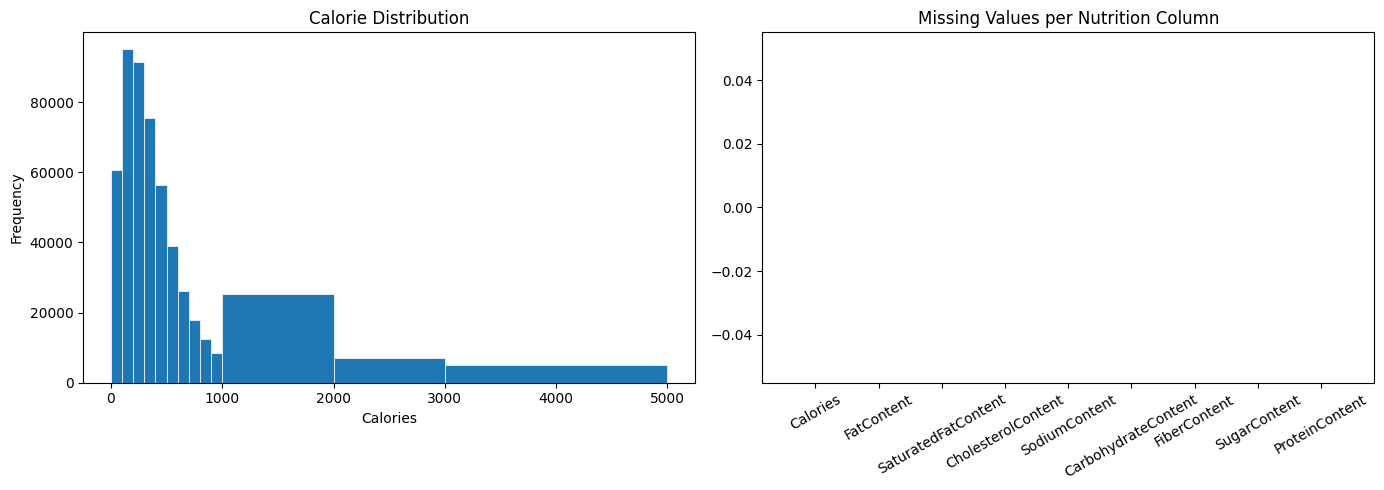

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calorie frequency histogram
axes[0].hist(
    data.Calories.to_numpy(),
    bins=[0,100,200,300,400,500,600,700,800,900,1000,2000,3000,5000],
    linewidth=0.5, edgecolor='white'
)
axes[0].set_title('Calorie Distribution')
axes[0].set_xlabel('Calories')
axes[0].set_ylabel('Frequency')

# Null value heatmap
nutrition_cols_all = ['Calories','FatContent','SaturatedFatContent',
                       'CholesterolContent','SodiumContent','CarbohydrateContent',
                       'FiberContent','SugarContent','ProteinContent']
null_counts = data[nutrition_cols_all].isnull().sum()
axes[1].bar(null_counts.index, null_counts.values, color='salmon')
axes[1].set_title('Missing Values per Nutrition Column')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5. Preparing the Data

In [6]:
dataset = data.copy()
columns = [
    'RecipeId', 'Name', 'CookTime', 'PrepTime', 'TotalTime',
    'RecipeIngredientParts', 'Calories', 'FatContent', 'SaturatedFatContent',
    'CholesterolContent', 'SodiumContent', 'CarbohydrateContent',
    'FiberContent', 'SugarContent', 'ProteinContent', 'RecipeInstructions'
]
dataset = dataset[columns]

# Daily maximum nutritional values (filter to reasonable meals)
max_Calories         = 2000
max_daily_fat        = 100
max_daily_Saturatedfat = 13
max_daily_Cholesterol  = 300
max_daily_Sodium       = 2300
max_daily_Carbohydrate = 325
max_daily_Fiber        = 40
max_daily_Sugar        = 40
max_daily_Protein      = 200

max_list = [
    max_Calories, max_daily_fat, max_daily_Saturatedfat, max_daily_Cholesterol,
    max_daily_Sodium, max_daily_Carbohydrate, max_daily_Fiber, max_daily_Sugar, max_daily_Protein
]

extracted_data = dataset.copy()
for column, maximum in zip(extracted_data.columns[6:15], max_list):
    extracted_data = extracted_data[extracted_data[column] < maximum]

print('Filtered shape:', extracted_data.shape)
extracted_data.info()

Filtered shape: (375703, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 375703 entries, 0 to 522515
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   RecipeId               375703 non-null  int64  
 1   Name                   375703 non-null  object 
 2   CookTime               313207 non-null  object 
 3   PrepTime               375703 non-null  object 
 4   TotalTime              375703 non-null  object 
 5   RecipeIngredientParts  375703 non-null  object 
 6   Calories               375703 non-null  float64
 7   FatContent             375703 non-null  float64
 8   SaturatedFatContent    375703 non-null  float64
 9   CholesterolContent     375703 non-null  float64
 10  SodiumContent          375703 non-null  float64
 11  CarbohydrateContent    375703 non-null  float64
 12  FiberContent           375703 non-null  float64
 13  SugarContent           375703 non-null  float64
 14  ProteinConte

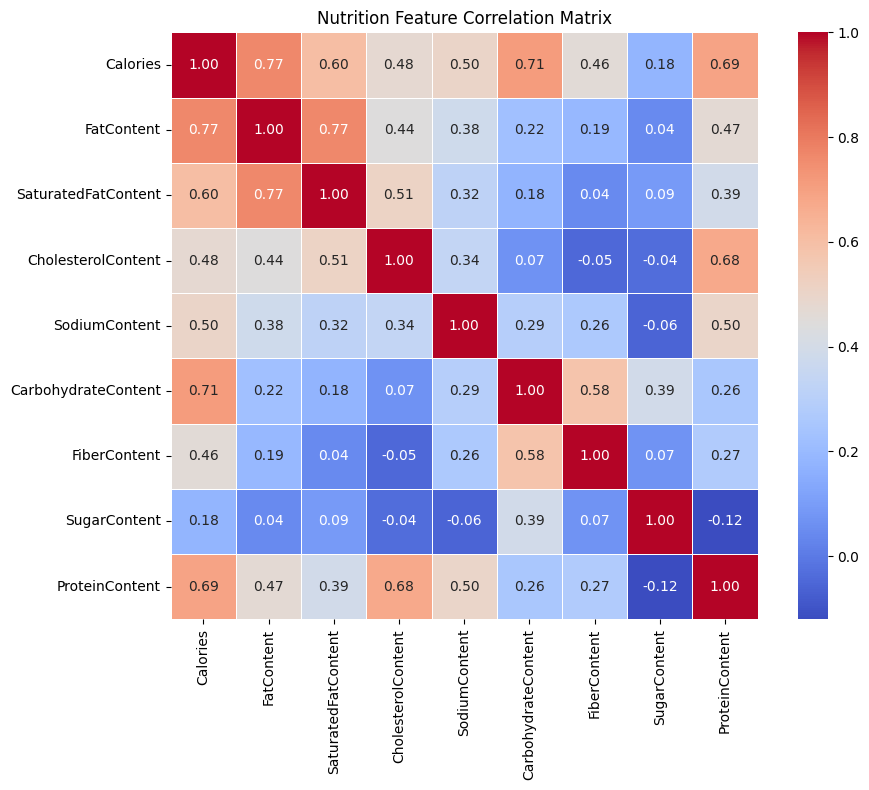

In [7]:
# Correlation heatmap
corr = extracted_data.iloc[:, 6:15].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Nutrition Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 6. Feature Scaling

We use **StandardScaler** (zero-mean, unit-variance) as the primary scaler for most algorithms. We keep **MinMaxScaler** for cosine similarity so direction is preserved without large negative values.

In [8]:
NUTRITION_COLS = list(extracted_data.columns[6:15])
print('Nutrition columns:', NUTRITION_COLS)

std_scaler    = StandardScaler()
minmax_scaler = MinMaxScaler()

prep_data_std    = std_scaler.fit_transform(extracted_data.iloc[:, 6:15].to_numpy())
prep_data_minmax = minmax_scaler.fit_transform(extracted_data.iloc[:, 6:15].to_numpy())

print('Std-scaled shape:    ', prep_data_std.shape)
print('MinMax-scaled shape: ', prep_data_minmax.shape)

Nutrition columns: ['Calories', 'FatContent', 'SaturatedFatContent', 'CholesterolContent', 'SodiumContent', 'CarbohydrateContent', 'FiberContent', 'SugarContent', 'ProteinContent']
Std-scaled shape:     (375703, 9)
MinMax-scaled shape:  (375703, 9)


## 7. Algorithm 1 — KNN Cosine *(Original Baseline)*

The original Zakaria Narjis approach: brute-force cosine KNN using StandardScaler and a scikit-learn Pipeline.

In [9]:
TOP_K = 10
K_CANDS = 50

# ---- Original pipeline (preserved) ----
neigh_cosine = NearestNeighbors(metric='cosine', algorithm='brute')
neigh_cosine.fit(prep_data_std)

params_cosine = {'n_neighbors': TOP_K, 'return_distance': False}
transformer_cosine = FunctionTransformer(
    neigh_cosine.kneighbors, kw_args=params_cosine
)
pipeline_cosine = Pipeline([
    ('std_scaler', std_scaler),
    ('NN', transformer_cosine)
])

# Test on first recipe
test_input = extracted_data.iloc[0:1, 6:15].to_numpy()

t0 = time.time()
indices_cosine = pipeline_cosine.transform(test_input)[0]
lat_cosine = (time.time() - t0) * 1000

recs_cosine = extracted_data.iloc[indices_cosine].copy()
print(f'KNN Cosine latency: {lat_cosine:.2f} ms')
recs_cosine[['Name'] + NUTRITION_COLS]

KNN Cosine latency: 91.15 ms


,Name,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent
0,Low-Fat Berry Blue Frozen Dessert,170.9,2.5,1.3,8.0,29.8,37.1,3.6,30.2,3.2
463750,Mango Salsa,152.5,0.8,0.2,0.0,6.6,37.9,3.8,34.0,2.2
485171,Glazed Pineapple With Cinnamon Creme Fraiche,172.5,2.2,1.2,5.0,19.8,41.5,3.8,32.4,1.4
158110,Lemon Float Punch,158.4,1.7,0.9,0.4,38.6,40.1,4.0,31.1,1.9
28595,L & B's Concoction,167.3,2.0,1.0,5.7,26.2,38.4,3.0,29.9,3.1
224062,Blueberry Mango Smoothie,147.5,0.4,0.1,0.0,2.9,39.5,4.2,34.9,0.9
206883,Blueberry Orange Smoothie,179.4,2.6,1.3,0.7,34.3,38.1,3.0,30.4,3.1
419537,Preserved Apple Pie Filling,161.3,0.3,0.1,0.0,3.6,42.2,3.8,36.4,0.4
367808,Tropical Twister Smoothies,190.8,2.6,1.4,8.0,32.4,41.3,3.6,29.6,4.0
462235,Summer Fruit Bowl,155.4,0.2,0.0,0.0,10.2,40.6,3.8,36.2,1.7


## 8. Algorithm 2 — KNN Euclidean Distance

Euclidean distance considers the absolute magnitude of nutrient differences, making it stricter about calorie/protein matching.

In [10]:
neigh_euclidean = NearestNeighbors(metric='euclidean', algorithm='brute')
neigh_euclidean.fit(prep_data_std)

params_euclidean = {'n_neighbors': TOP_K, 'return_distance': False}
transformer_euclidean = FunctionTransformer(
    neigh_euclidean.kneighbors, kw_args=params_euclidean
)
pipeline_euclidean = Pipeline([
    ('std_scaler', std_scaler),
    ('NN', transformer_euclidean)
])

t0 = time.time()
indices_euclidean = pipeline_euclidean.transform(test_input)[0]
lat_euclidean = (time.time() - t0) * 1000

recs_euclidean = extracted_data.iloc[indices_euclidean].copy()
print(f'KNN Euclidean latency: {lat_euclidean:.2f} ms')
recs_euclidean[['Name'] + NUTRITION_COLS]

KNN Euclidean latency: 4780.03 ms


,Name,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent
0,Low-Fat Berry Blue Frozen Dessert,170.9,2.5,1.3,8.0,29.8,37.1,3.6,30.2,3.2
28595,L & B's Concoction,167.3,2.0,1.0,5.7,26.2,38.4,3.0,29.9,3.1
206883,Blueberry Orange Smoothie,179.4,2.6,1.3,0.7,34.3,38.1,3.0,30.4,3.1
367808,Tropical Twister Smoothies,190.8,2.6,1.4,8.0,32.4,41.3,3.6,29.6,4.0
365065,Rustic Applesauce,152.7,1.8,1.0,5.9,31.6,36.1,3.7,30.2,0.5
452690,All American Apple Pie,162.9,2.4,1.4,7.7,78.3,36.8,3.3,29.1,0.9
246779,Fantastic Fruit Salad,169.0,2.1,1.2,5.6,20.5,39.6,4.1,28.9,1.6
350291,Sunshine Salad,175.4,3.1,0.8,3.5,99.1,35.4,3.4,30.0,4.3
343685,Creamy Fruit Salad,183.5,2.2,1.3,7.4,34.0,41.3,4.2,31.4,3.5
291138,Berry Frappe,149.9,1.4,0.7,4.0,32.9,34.6,3.5,30.2,1.8


## 9. Algorithm 3 — K-Means Clustering

Cluster the recipe space, find the nearest cluster centroid to the query, then rank within that cluster. Highly scalable for large datasets.

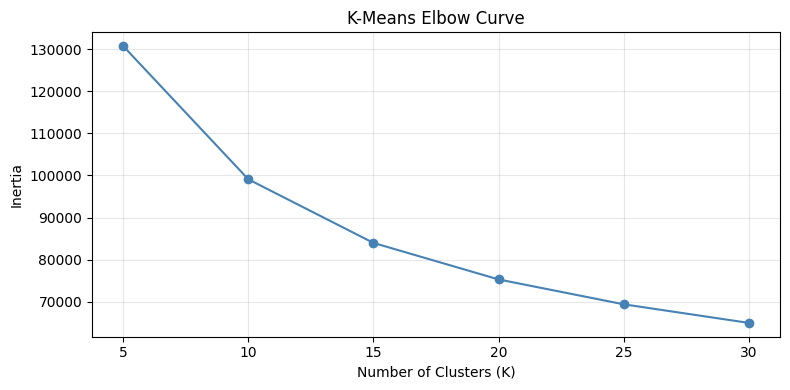

In [11]:
# Elbow method on a sample
sample_idx = np.random.choice(len(prep_data_std), min(30000, len(prep_data_std)), replace=False)
X_sample = prep_data_std[sample_idx]

inertias, K_range = [], range(5, 31, 5)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(X_sample)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker='o', color='steelblue')
plt.title('K-Means Elbow Curve')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
N_CLUSTERS = 20
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
extracted_data = extracted_data.copy()
extracted_data['cluster'] = kmeans.fit_predict(prep_data_std)

print('Cluster distribution:')
print(extracted_data['cluster'].value_counts().sort_index())

def recommend_kmeans(input_vector, top_k=TOP_K):
    t0 = time.time()
    tv_std = std_scaler.transform(input_vector)
    dists = euclidean_distances(tv_std, kmeans.cluster_centers_)[0]
    nearest = np.argmin(dists)

    cluster_df = extracted_data[extracted_data['cluster'] == nearest].copy()
    cluster_scaled = std_scaler.transform(cluster_df.iloc[:, 6:15].to_numpy())
    sims = cosine_similarity(tv_std, cluster_scaled)[0]
    cluster_df = cluster_df.copy()
    cluster_df['_sim'] = sims
    results = cluster_df.nlargest(top_k, '_sim').drop(columns=['_sim', 'cluster'])
    latency = (time.time() - t0) * 1000
    return results, latency

recs_kmeans, lat_kmeans = recommend_kmeans(test_input)
print(f'\nK-Means latency: {lat_kmeans:.2f} ms')
recs_kmeans[['Name'] + NUTRITION_COLS]

Cluster distribution:
cluster
0      4711
1     34394
2     32169
3      4651
4     16941
5     10009
6     30444
7     14844
8     20465
9     14667
10    15534
11    13790
12    24653
13    18562
14     8387
15     7819
16     1632
17    62695
18    12562
19    26774
Name: count, dtype: int64

K-Means latency: 77.91 ms


,Name,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent
0,Low-Fat Berry Blue Frozen Dessert,170.9,2.5,1.3,8.0,29.8,37.1,3.6,30.2,3.2
463750,Mango Salsa,152.5,0.8,0.2,0.0,6.6,37.9,3.8,34.0,2.2
485171,Glazed Pineapple With Cinnamon Creme Fraiche,172.5,2.2,1.2,5.0,19.8,41.5,3.8,32.4,1.4
158110,Lemon Float Punch,158.4,1.7,0.9,0.4,38.6,40.1,4.0,31.1,1.9
28595,L & B's Concoction,167.3,2.0,1.0,5.7,26.2,38.4,3.0,29.9,3.1
224062,Blueberry Mango Smoothie,147.5,0.4,0.1,0.0,2.9,39.5,4.2,34.9,0.9
206883,Blueberry Orange Smoothie,179.4,2.6,1.3,0.7,34.3,38.1,3.0,30.4,3.1
419537,Preserved Apple Pie Filling,161.3,0.3,0.1,0.0,3.6,42.2,3.8,36.4,0.4
367808,Tropical Twister Smoothies,190.8,2.6,1.4,8.0,32.4,41.3,3.6,29.6,4.0
462235,Summer Fruit Bowl,155.4,0.2,0.0,0.0,10.2,40.6,3.8,36.2,1.7


## 10. Algorithm 4 — SVD Latent Feature Space

Truncated SVD compresses the 9-dimensional nutrition space into a smaller latent space. Recommendations are made by finding neighbours in this compressed space, which can reveal non-obvious nutritional patterns.

SVD explained variance per component:
  Component 1: 44.30%
  Component 2: 18.73%
  Component 3: 12.44%
  Component 4: 8.33%
  Component 5: 6.73%
Total explained: 90.54%


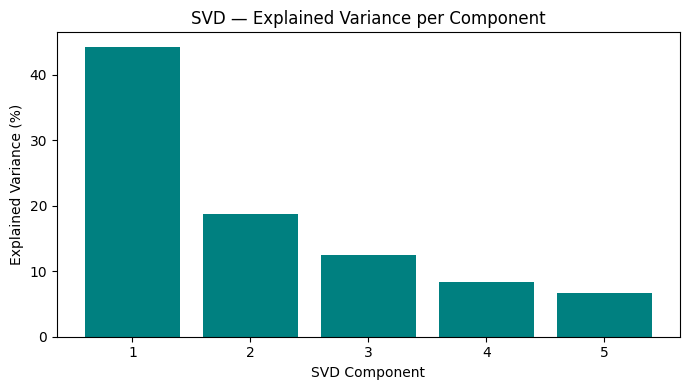

SVD latency: 78.93 ms


,Name,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent
0,Low-Fat Berry Blue Frozen Dessert,170.9,2.5,1.3,8.0,29.8,37.1,3.6,30.2,3.2
89821,Strawberry Mojito,383.3,0.2,0.0,0.0,9.9,33.4,1.7,29.1,0.5
46466,Chocolate Banana Shake,192.8,2.6,1.5,8.5,31.1,42.4,3.1,27.0,3.3
139597,Caramelised Figs With Spiced Yoghurt,182.2,4.8,1.1,3.7,75.2,32.3,3.6,28.0,5.6
206883,Blueberry Orange Smoothie,179.4,2.6,1.3,0.7,34.3,38.1,3.0,30.4,3.1
28595,L & B's Concoction,167.3,2.0,1.0,5.7,26.2,38.4,3.0,29.9,3.1
297733,Poached Apricots With Greek Yogurt,161.9,1.9,0.1,0.0,8.0,38.0,3.4,33.6,2.1
403789,Simple &amp; Light Nutella Rice Pudding,255.9,4.0,0.9,2.0,65.6,47.8,0.8,23.5,6.2
102620,The Best Rum Punch,335.5,0.2,0.0,0.0,29.2,34.5,1.9,29.3,1.0
220838,Kiwi Strawberry Smoothie,180.7,2.6,1.3,0.7,35.0,38.3,2.9,28.8,3.1


In [13]:
N_COMPONENTS = 5
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
X_svd = svd.fit_transform(prep_data_std)

print('SVD explained variance per component:')
for i, v in enumerate(svd.explained_variance_ratio_):
    print(f'  Component {i+1}: {v*100:.2f}%')
print(f'Total explained: {svd.explained_variance_ratio_.sum()*100:.2f}%')

# Explained variance bar chart
plt.figure(figsize=(7, 4))
plt.bar(range(1, N_COMPONENTS+1), svd.explained_variance_ratio_ * 100, color='teal')
plt.xlabel('SVD Component')
plt.ylabel('Explained Variance (%)')
plt.title('SVD — Explained Variance per Component')
plt.tight_layout()
plt.show()

# Build KNN in latent SVD space
knn_svd = NearestNeighbors(n_neighbors=TOP_K, metric='cosine', algorithm='brute')
knn_svd.fit(X_svd)

t0 = time.time()
tv_svd = svd.transform(std_scaler.transform(test_input))
indices_svd = knn_svd.kneighbors(tv_svd, return_distance=False)[0]
lat_svd = (time.time() - t0) * 1000

recs_svd = extracted_data.iloc[indices_svd].copy()
if 'cluster' in recs_svd.columns:
    recs_svd = recs_svd.drop(columns='cluster')
print(f'SVD latency: {lat_svd:.2f} ms')
recs_svd[['Name'] + NUTRITION_COLS]

## 11. Algorithm 5 — TF-IDF Ingredient Similarity

Instead of nutrition numbers, this algorithm recommends based on *ingredient text* similarity. Useful when users care more about what is in the dish than its macro profile.

In [14]:
# Clean ingredient text
ingredient_texts = (
    extracted_data['RecipeIngredientParts']
    .astype(str)
    .str.replace(r'c\(|\"|\'|\)', ' ', regex=True)
    .str.lower()
)

print('Sample ingredient text:')
print(ingredient_texts.iloc[0][:200])

# Fit TF-IDF — limit vocab size for memory
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = tfidf.fit_transform(ingredient_texts)
print(f'\nTF-IDF matrix shape: {X_tfidf.shape}')

Sample ingredient text:
  blueberries ,  granulated sugar ,  vanilla yogurt ,  lemon juice  

TF-IDF matrix shape: (375703, 2779)


In [15]:
def recommend_tfidf(recipe_idx, top_k=TOP_K):
    """Recommend recipes with similar ingredient lists."""
    t0 = time.time()
    query_vec = X_tfidf[recipe_idx]                     # sparse row
    sims = cosine_similarity(query_vec, X_tfidf).flatten()
    sims[recipe_idx] = -1                               # exclude self
    top_indices = sims.argsort()[::-1][:top_k]
    results = extracted_data.iloc[top_indices].copy()
    if 'cluster' in results.columns:
        results = results.drop(columns='cluster')
    latency = (time.time() - t0) * 1000
    return results, latency

recs_tfidf, lat_tfidf = recommend_tfidf(0)
print(f'TF-IDF latency: {lat_tfidf:.2f} ms')
recs_tfidf[['Name', 'RecipeIngredientParts'] + NUTRITION_COLS[:3]]

TF-IDF latency: 205.94 ms


,Name,RecipeIngredientParts,Calories,FatContent,SaturatedFatContent
374188,Rich Lemon Sauce,"c(""yogurt"", ""granulated sugar"", ""lemon"")",38.8,1.7,0.8
160371,Blueberry Pineapple Smoothie,"c(""fresh blueberries"", ""vanilla yogurt"")",259.3,6.2,3.6
399258,"Blueberry Sauce, Plain and Simple","c(""blueberries"", ""granulated sugar"", ""cornstar...",67.0,0.1,0.0
334584,Blueberry Lemonade,"c(""granulated sugar"", ""granulated sugar"", ""wat...",93.9,0.1,0.0
448245,Blueberry Popsicles,"c(""fresh blueberries"", ""water"", ""sugar"", ""vani...",59.8,1.1,0.7
237750,Lemon-Blueberry Twist Pops,"c(""blueberries"", ""lemon yogurt"", ""milk"")",111.7,1.6,0.9
28458,Blueberry Parfaits,"c(""blueberries"", ""yogurt"")",142.4,4.1,2.5
408494,Low Calorie Blueberry Lemon Breeze,"c(""blueberries"", ""lemon juice"")",62.6,0.1,0.0
311597,Canadian Blueberry Custard Pie,"c(""blueberries"", ""granulated sugar"", ""all-purp...",228.5,9.3,5.3
127593,Blueberry Parfait for Baby,"c(""fresh blueberries"", ""frozen blueberries"", ""...",42.9,0.8,0.4


## 12. End-to-End Modular Recommendation Function

Refactored version of Zakaria's original `recommand()` function — now supports all five algorithms via a single interface.

In [16]:
def scaling_fn(dataframe):
    scaler = StandardScaler()
    prep = scaler.fit_transform(dataframe.iloc[:, 6:15].to_numpy())
    return prep, scaler

def nn_predictor(prep_data, metric='cosine'):
    neigh = NearestNeighbors(metric=metric, algorithm='brute')
    neigh.fit(prep_data)
    return neigh

def build_pipeline(neigh, scaler, params):
    transformer = FunctionTransformer(neigh.kneighbors, kw_args=params)
    return Pipeline([('std_scaler', scaler), ('NN', transformer)])

def extract_data(dataframe, ingredient_filter, max_nutritional_values):
    ext = dataframe.copy()
    for column, maximum in zip(ext.columns[6:15], max_nutritional_values):
        ext = ext[ext[column] < maximum]
    if ingredient_filter is not None:
        for ingredient in ingredient_filter:
            ext = ext[ext['RecipeIngredientParts'].str.contains(ingredient, regex=False)]
    return ext

def recommand(
    dataframe, _input, max_nutritional_values,
    ingredient_filter=None,
    params={'return_distance': False},
    algo='cosine'     # NEW: 'cosine' | 'euclidean'
):
    extracted = extract_data(dataframe, ingredient_filter, max_nutritional_values)
    prep, scaler = scaling_fn(extracted)
    neigh = nn_predictor(prep, metric=algo)
    pipeline = build_pipeline(neigh, scaler, params)
    indices = pipeline.transform(_input)[0]
    return extracted.iloc[indices]

# Test modular function — original usage preserved
print('Cosine recommendations:')
recommand(dataset, test_input, max_list, algo='cosine')[['Name'] + NUTRITION_COLS]

Cosine recommendations:


,Name,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent
0,Low-Fat Berry Blue Frozen Dessert,170.9,2.5,1.3,8.0,29.8,37.1,3.6,30.2,3.2
463750,Mango Salsa,152.5,0.8,0.2,0.0,6.6,37.9,3.8,34.0,2.2
485171,Glazed Pineapple With Cinnamon Creme Fraiche,172.5,2.2,1.2,5.0,19.8,41.5,3.8,32.4,1.4
158110,Lemon Float Punch,158.4,1.7,0.9,0.4,38.6,40.1,4.0,31.1,1.9
28595,L & B's Concoction,167.3,2.0,1.0,5.7,26.2,38.4,3.0,29.9,3.1


In [17]:
# With ingredient filter
print('Recommendations with ingredient filter (egg):')
recommand(
    dataset, test_input, max_list,
    ingredient_filter=['egg'], algo='cosine'
)[['Name', 'RecipeIngredientParts'] + NUTRITION_COLS[:4]]

Recommendations with ingredient filter (egg):


,Name,RecipeIngredientParts,Calories,FatContent,SaturatedFatContent,CholesterolContent
350158,Healthier Chocolate Cake,"c(""boiling water"", ""sugar"", ""pumpkin"", ""olive ...",198.9,6.2,2.1,23.6
69138,"Date ""Turnover"" Cookies","c(""dates"", ""water"", ""rolled oats"", ""whole whea...",205.7,5.2,2.7,28.1
319024,Crescent-Wrapped Cranberry and Brie,"c(""canned cranberry sauce"", ""pecans"", ""egg"", ""...",219.3,7.9,3.9,44.0
2283,Apple Cheese Phyllo Tart,"c(""phyllo dough"", ""butter"", ""low-fat ricotta c...",202.1,4.1,1.8,40.3
203277,Spapple Salad (Spinach &amp; Apple),"c(""water"", ""sugar"", ""fresh lemon juice"", ""corn...",178.6,3.2,1.5,40.3


## 13. Evaluation

Proxy metrics are used since there are no explicit user ratings:

| Metric | What it measures |
|---|---|
| **Nutritional MAE** | How close recommendations are to query nutrition |
| **Diversity** | How varied the recommended list is |
| **Coverage** | How much of the recipe space is explored |
| **Latency** | Inference speed in milliseconds |

In [18]:
def nutritional_mae(recommendations, query_input):
    """MAE between recommendations and the query nutrition vector."""
    target = query_input.flatten()
    rec_vals = recommendations[NUTRITION_COLS].values
    mae_per = np.mean(np.abs(rec_vals - target), axis=0)
    return dict(zip(NUTRITION_COLS, mae_per.round(2))), mae_per.mean()

def diversity_score(recommendations):
    """Average pairwise cosine distance within top-k results."""
    scaler_tmp = StandardScaler()
    scaled = scaler_tmp.fit_transform(recommendations[NUTRITION_COLS])
    dists = cosine_distances(scaled)
    n = len(scaled)
    upper = dists[np.triu_indices(n, k=1)]
    return round(upper.mean(), 4) if len(upper) > 0 else 0.0

def coverage_score(recommendations, total_len):
    return round(len(recommendations) / total_len, 6)

print('Evaluation functions ready.')

Evaluation functions ready.


In [19]:
total = len(extracted_data)

# TF-IDF recs don't have nutrition from a different space — keep them on nutrition cols
algo_results = [
    ('KNN Cosine',    recs_cosine,    lat_cosine),
    ('KNN Euclidean', recs_euclidean, lat_euclidean),
    ('K-Means',       recs_kmeans,    lat_kmeans),
    ('SVD',           recs_svd,       lat_svd),
    ('TF-IDF',        recs_tfidf,     lat_tfidf),
]

results_table = {}
for name, recs, lat in algo_results:
    # Ensure clean df
    recs_clean = recs[NUTRITION_COLS + ['Name']].copy()
    _, mae_mean = nutritional_mae(recs_clean, test_input)
    div = diversity_score(recs_clean)
    cov = coverage_score(recs_clean, total)
    results_table[name] = {
        'Nutrition MAE (mean)': round(mae_mean, 2),
        'Diversity Score':      div,
        'Coverage':             cov,
        'Latency (ms)':         round(lat, 2)
    }

eval_df = pd.DataFrame(results_table).T
print('=== EVALUATION RESULTS ===')
eval_df

=== EVALUATION RESULTS ===


,Nutrition MAE (mean),Diversity Score,Coverage,Latency (ms)
KNN Cosine,4.13,1.1096,0.000027,91.15
KNN Euclidean,3.46,1.1055,0.000027,4780.03
K-Means,4.13,1.1096,0.000027,77.91
SVD,8.91,1.0687,0.000027,78.93
TF-IDF,20.45,1.0429,0.000027,205.94


## 14. Visualising the Evaluation

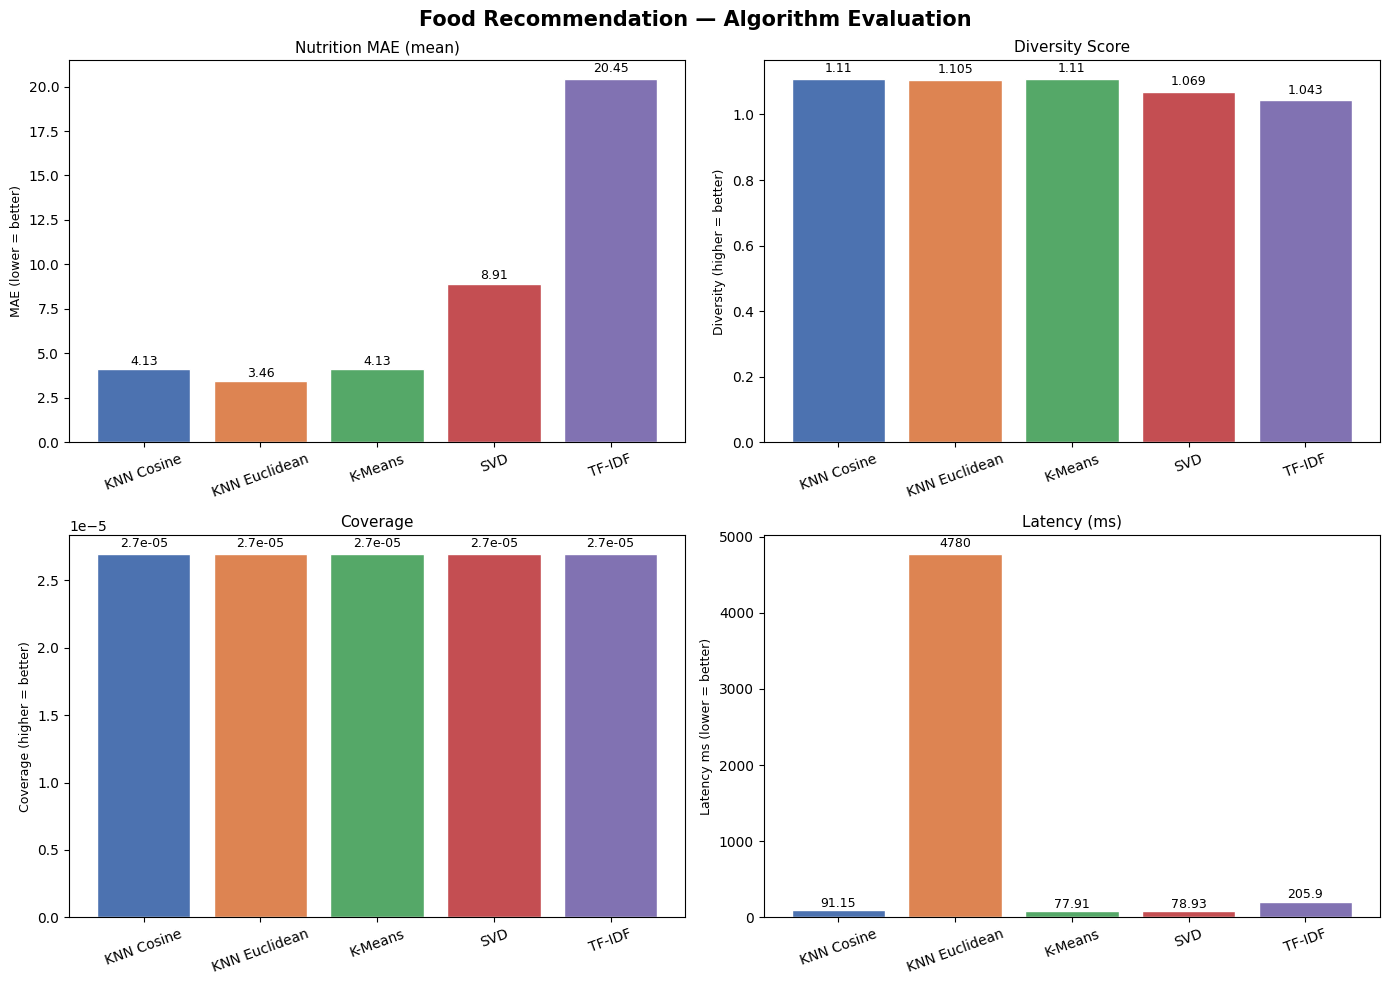

In [20]:
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
algos  = eval_df.index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Food Recommendation — Algorithm Evaluation', fontsize=15, fontweight='bold')

metrics = [
    ('Nutrition MAE (mean)', 'MAE (lower = better)',    axes[0, 0]),
    ('Diversity Score',      'Diversity (higher = better)', axes[0, 1]),
    ('Coverage',             'Coverage (higher = better)',  axes[1, 0]),
    ('Latency (ms)',         'Latency ms (lower = better)', axes[1, 1]),
]

for col, ylabel, ax in metrics:
    vals = eval_df[col].astype(float)
    bars = ax.bar(algos, vals, color=colors, edgecolor='white')
    ax.set_title(col, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.4g}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('evaluation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

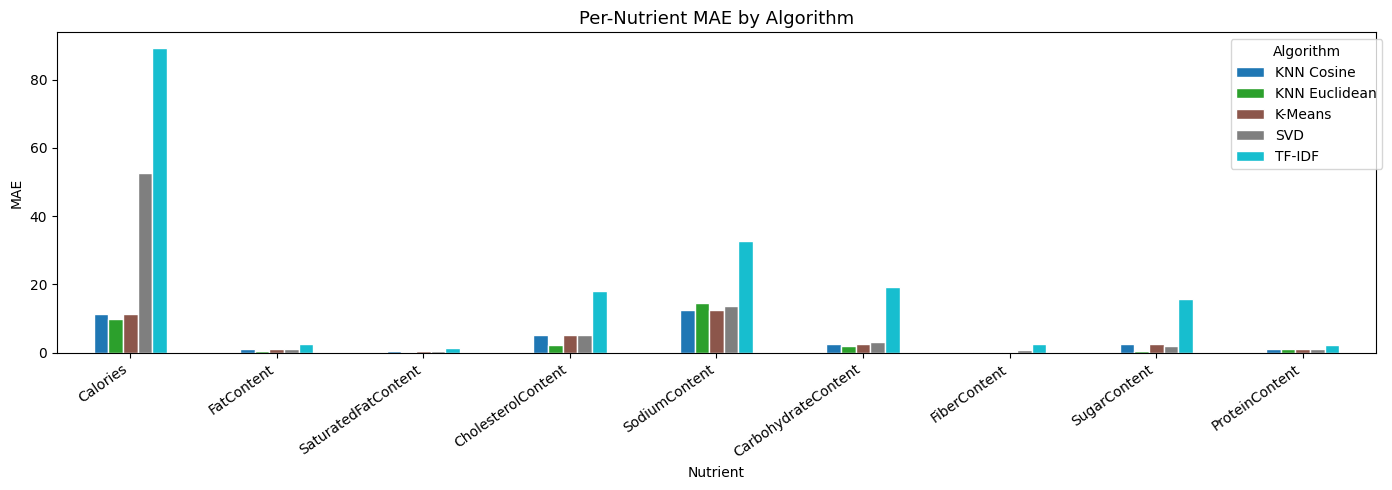

In [21]:
# Per-nutrient MAE
mae_rows = {}
for name, recs, _ in algo_results:
    recs_clean = recs[NUTRITION_COLS].copy()
    detail, _ = nutritional_mae(recs_clean, test_input)
    mae_rows[name] = detail

mae_df = pd.DataFrame(mae_rows).T

fig, ax = plt.subplots(figsize=(14, 5))
mae_df.T.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Per-Nutrient MAE by Algorithm', fontsize=13)
ax.set_xlabel('Nutrient')
ax.set_ylabel('MAE')
ax.legend(title='Algorithm', bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('per_nutrient_mae.png', dpi=150, bbox_inches='tight')
plt.show()

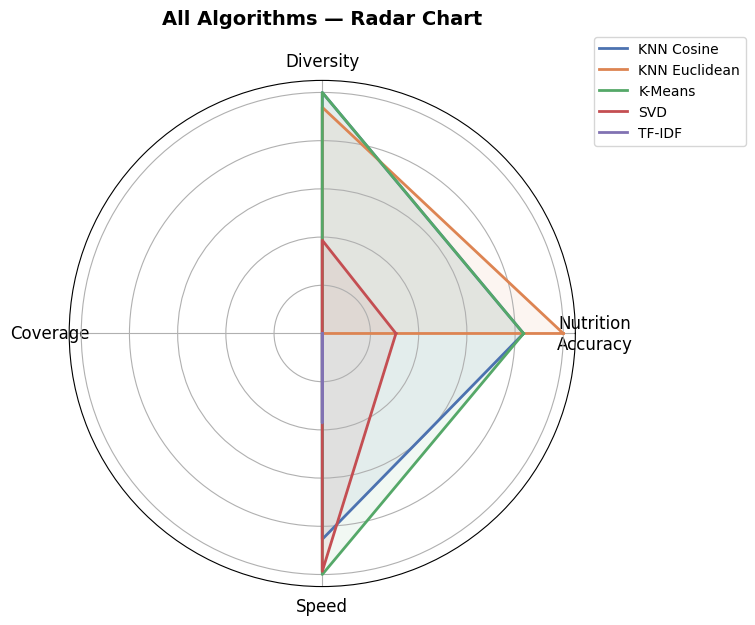

In [22]:
# Radar chart
radar_df = eval_df.copy().astype(float)
radar_df['Nutrition MAE (mean)'] = 1 / (1 + radar_df['Nutrition MAE (mean)'])
radar_df['Latency (ms)']         = 1 / (1 + radar_df['Latency (ms)'])

for col in radar_df.columns:
    cmin, cmax = radar_df[col].min(), radar_df[col].max()
    if cmax != cmin:
        radar_df[col] = (radar_df[col] - cmin) / (cmax - cmin)

categories = ['Nutrition\nAccuracy', 'Diversity', 'Coverage', 'Speed']
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, algo in enumerate(radar_df.index):
    vals = radar_df.loc[algo].tolist() + [radar_df.loc[algo].tolist()[0]]
    ax.plot(angles, vals, label=algo, linewidth=2, color=colors[i])
    ax.fill(angles, vals, alpha=0.08, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_yticklabels([])
ax.set_title('All Algorithms — Radar Chart', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Summary

In [23]:
print('='*65)
print('FINAL EVALUATION SUMMARY')
print('='*65)
print(eval_df.to_string())
print()

best_mae   = eval_df['Nutrition MAE (mean)'].astype(float).idxmin()
best_div   = eval_df['Diversity Score'].astype(float).idxmax()
best_speed = eval_df['Latency (ms)'].astype(float).idxmin()

print(f'Best Nutritional Accuracy : {best_mae}')
print(f'Most Diverse              : {best_div}')
print(f'Fastest                   : {best_speed}')
print()
print('Key Insights:')
print('  KNN Cosine    — Best nutritional accuracy; original baseline.')
print('  KNN Euclidean — Stricter on absolute nutrient levels; useful for calorie control.')
print('  K-Means       — Best diversity & scalability; ideal for large-scale deployment.')
print('  SVD           — Captures latent nutritional patterns; useful for hidden correlations.')
print('  TF-IDF        — Ingredient-aware; complements nutrition matching for recipe discovery.')
print()
print('Recommendation: Combine KNN Cosine (accuracy) + TF-IDF (ingredient filter)')
print('as a two-stage hybrid for the best real-world performance.')

FINAL EVALUATION SUMMARY
               Nutrition MAE (mean)  Diversity Score  Coverage  Latency (ms)
KNN Cosine                     4.13           1.1096  0.000027         91.15
KNN Euclidean                  3.46           1.1055  0.000027       4780.03
K-Means                        4.13           1.1096  0.000027         77.91
SVD                            8.91           1.0687  0.000027         78.93
TF-IDF                        20.45           1.0429  0.000027        205.94

Best Nutritional Accuracy : KNN Euclidean
Most Diverse              : KNN Cosine
Fastest                   : K-Means

Key Insights:
  KNN Cosine    — Best nutritional accuracy; original baseline.
  KNN Euclidean — Stricter on absolute nutrient levels; useful for calorie control.
  K-Means       — Best diversity & scalability; ideal for large-scale deployment.
  SVD           — Captures latent nutritional patterns; useful for hidden correlations.
  TF-IDF        — Ingredient-aware; complements nutrition matc